In [8]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense

In [9]:
# 데이타 불러오기
(x_train,y_train),(x_test,y_test) = mnist.load_data()

# 데이터 정규화
x_train = x_train / 255.0
x_test = x_test / 255.0

# CNN 입력 형태 (28,28) => (28,28,1)

x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

print(x_train.shape) # (60000, 28, 28, 1)
print(x_test.shape) # (10000, 28, 28, 1)

# CNN 모델
model = Sequential([
    Input(shape=(28,28,1)),
    Conv2D(32, (3,3) , activation="relu"),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128,activation="relu"),
    Dense(10,activation="softmax")
])

model.summary()

# 컴파일
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# 학습
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

# 평가
loss , accuracy = model.evaluate(x_test,y_test)
print("정확도",  accuracy)


(60000, 28, 28, 1)
(10000, 28, 28, 1)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

KeyboardInterrupt: 

In [ ]:
model.save("mnist_cnn.keras")

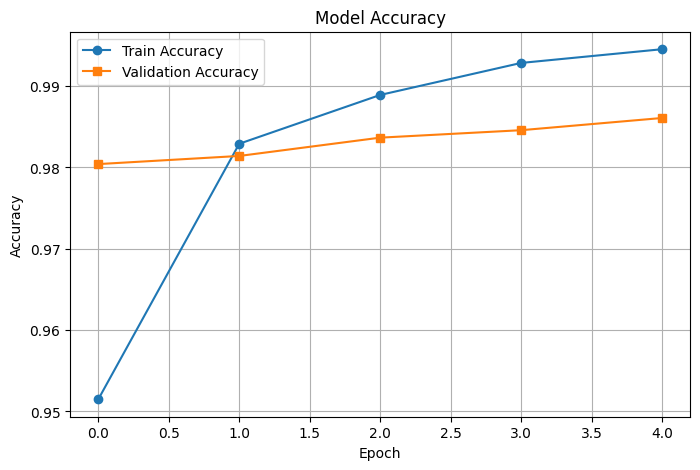

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], marker="o", label="Train Accuracy")
plt.plot(history.history["val_accuracy"], marker="s", label="Validation Accuracy")

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()

plt.show()

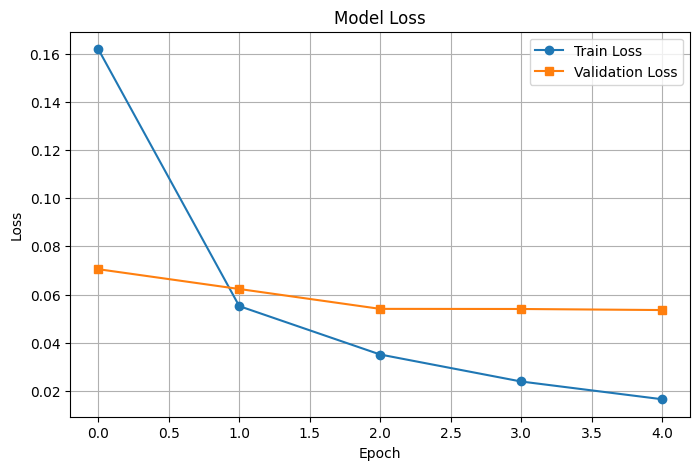

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], marker="o", label="Train Loss")
plt.plot(history.history["val_loss"], marker="s", label="Validation Loss")

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()

plt.show()

In [ ]:
!pip -q install gradio

import gradio as gr
print(gr.__version__)
import gradio as gr
import numpy as np
from PIL import Image
from tensorflow.keras.models import load_model

model = load_model("mnist_cnn.keras")


# ------------------------------
# 예측 함수
# ------------------------------

def predict(data):

    if data is None:
        return {}, None

    # Gradio5.x
    if isinstance(data, dict):

        img = data.get("composite", None)

        if img is None:
            return {}, None

    else:
        img = data

    # 흑백
    from PIL import Image

    img = Image.fromarray(img)
    img = img.convert("L")

    # 28x28
    img28 = img.resize((28,28))

    # MNIST 형태
    img28 = Image.fromarray(
        255 - np.array(img28)
    )

    # 정규화
    x = np.array(img28).astype("float32")/255.0

    x = x.reshape(1,28,28,1)

    pred = model.predict(x,verbose=0)[0]

    result = {
        str(i): float(pred[i])
        for i in range(10)
    }

    return result, img28


# ------------------------------
# UI
# ------------------------------

with gr.Blocks() as demo:

    gr.Markdown("# ✍️ CNN 손글씨 숫자 인식")

    gr.Markdown(
        "숫자를 그리고 마우스를 놓으면 자동으로 예측합니다."
    )

    with gr.Row():

        sketch = gr.Sketchpad(
            height=280,
            width=280
        )

        preview = gr.Image(
            label="28×28 CNN 입력",
            interactive=False
        )

    label = gr.Label(
        num_top_classes=3,
        label="예측 결과"
    )

    sketch.change(
        fn=predict,
        inputs=sketch,
        outputs=[
            label,
            preview
        ]
    )

demo.launch(debug=True)

5.50.0
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://0abd62fc81b3ac8e12.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


content_type multipart/form-data; boundary=----WebKitFormBoundaryl9Yeg5WRvnNS7aEQ
content_type multipart/form-data; boundary=----WebKitFormBoundarybwe6GQ4PY7WVEBkk
content_type multipart/form-data; boundary=----WebKitFormBoundary5hFUlgN16b8cSkBg
content_type multipart/form-data; boundary=----WebKitFormBoundaryMI5Zc4a2lmDyBtJD
content_type multipart/form-data; boundary=----WebKitFormBoundaryCzgtAFHqYRtvzzUp
content_type multipart/form-data; boundary=----WebKitFormBoundaryPrwDxYdBzSOoQOKt
content_type multipart/form-data; boundary=----WebKitFormBoundarytRqa0chzN2NAjoJJ
content_type multipart/form-data; boundary=----WebKitFormBoundarychBbsWx1noMYcFOx
content_type multipart/form-data; boundary=----WebKitFormBoundaryXsYYxwBmZmhgLTax
content_type multipart/form-data; boundary=----WebKitFormBoundaryXQUwRWKlHgIdhTlr
content_type multipart/form-data; boundary=----WebKitFormBoundaryLv5L3wCji238ZiaI
content_type multipart/form-data; boundary=----WebKitFormBoundaryiXrLJ5cVKWwmUkzq
content_type mul